# HiStrA Python vs C# Verification & Bridge Scenario Analysis

This notebook demonstrates the in-process Python HiStrA solver across **benchmark models** (`benchmark_1`, `benchmark_2`) and **full-scale 3D masonry bridge models** (`random_001` through `random_006`), comparing Python execution against authoritative C# `.Results` databases.

### Verification & Engineering Analysis Workflows:
1. **Equilibrium & Capacity Curves**: Vertical Reaction / Balancing Reaction vs Pier Top Settlement ($R_z$ vs $U_z$).
2. **Scour Progression Analysis**: Upstream Scour Depth Ratio ($0\% \to 20\% \to 40\%$) vs Pier Settlement ($U_z$) and Transverse Drift ($U_y$).
3. **Pier Top Kinematics**: Displacements ($U_x, U_y, U_z$) at the top of the pier where superstructure loads are transferred.
4. **Pier Rotation & Tilt ($X$-Direction)**: Transverse tilt comparison from vertical differential settlement ($\theta_x = \Delta U_z / B_{\mathrm{pier}}$) versus lateral transverse drift ($\theta_x = \Delta U_y / H_{\mathrm{pier}}$) across both scour progression and live load pushover.
5. **Multi-Model Batch Parity Benchmark**: Cross-model comparison across all 6 random models.


In [1]:
from __future__ import annotations

import copy
import json
import math
from pathlib import Path
import sqlite3
import time
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np

from histra.io.hr_loader import load_model
from histra.solver import AnalysisSession
from histra.solver.model_manager import ModelManager
from histra.solver.output_projection import compute_model_point_displacements

# Matplotlib formatting and visualization style
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["grid.alpha"] = 0.5
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["figure.autolayout"] = True

print("HiStrA Python environment loaded successfully.")


HiStrA Python environment loaded successfully.


In [2]:
# ==============================================================================
# Geometry and Result Synchronization Helpers
# ==============================================================================

SOIL_MATERIAL_KEY = 146
SOIL_REMOVED_MATERIAL_KEY = 147
PIER_CENTRES_X = (502.0, 846.0)
PIER_X = 502.0
PIER_LENGTH = 139.8
PIER_Y = 0.0
PIER_WIDTH = 342.4
PIER_HEIGHT = 225.0  # Height from foundation base (z=-225) to top (z=0)
SCOUR_ROWS_1 = 3
SCOUR_RATIO_2 = 0.4


def _centre(interface) -> tuple[float, float, float]:
    vertices = interface.vint3d
    return tuple(sum(getattr(v, axis) for v in vertices) / 4.0 for axis in ("x", "y", "z"))


def pier_foundation_interface_keys(
    model,
    pier_centres_x: tuple[float, ...] = PIER_CENTRES_X,
    pier_length: float = PIER_LENGTH,
) -> list[int]:
    half_len = pier_length / 2.0
    return sorted(
        int(intf.key)
        for intf in model.collections.interfaces.values()
        if "Restraint" in (intf.parent_type_element1, intf.parent_type_element2)
        and any(abs(_centre(intf)[0] - px) <= half_len + 1.0e-4 for px in pier_centres_x)
    )


def first_rows_interface_keys(model, rows: int = SCOUR_ROWS_1, pier_x: float = PIER_X) -> list[int]:
    ys = sorted({
        round(_centre(i)[1], 4) for i in model.collections.interfaces.values()
        if "Restraint" in (i.parent_type_element1, i.parent_type_element2)
        and abs(_centre(i)[0] - pier_x) <= (PIER_LENGTH / 2.0) + 1.0e-4
    })
    keep = set(ys[:rows])
    return sorted(
        int(i.key) for i in model.collections.interfaces.values()
        if "Restraint" in (i.parent_type_element1, i.parent_type_element2)
        and abs(_centre(i)[0] - pier_x) <= (PIER_LENGTH / 2.0) + 1.0e-4
        and round(_centre(i)[1], 4) in keep
    )


def upstream_interface_keys(
    model,
    delta: float,
    pier_x: float = PIER_X,
    pier_length: float = PIER_LENGTH,
    pier_y: float = PIER_Y,
    pier_width: float = PIER_WIDTH,
) -> list[int]:
    left = pier_x - pier_length / 2.0
    right = pier_x + pier_length / 2.0
    upstream = pier_y - pier_width / 2.0
    limit = upstream + pier_width * float(delta)
    selected: list[int] = []
    for intf in model.collections.interfaces.values():
        if "Restraint" not in (intf.parent_type_element1, intf.parent_type_element2):
            continue
        x, y, _ = _centre(intf)
        if left - 1e-4 <= x <= right + 1e-4 and upstream - 1e-4 <= y <= limit + 1e-4:
            selected.append(int(intf.key))
    return sorted(selected)


def build_aligned_step_history(
    model,
    executions: list,
    csharp_results_path: Path | str,
    preferred_mp_key: int | None = None,
) -> dict:
    """Synchronize Python and C# steps strictly by (AnalysisKey, Step) pairs."""
    csharp_results_path = Path(csharp_results_path)
    cs_reactions = {}
    cs_mps = {}

    if csharp_results_path.exists():
        with sqlite3.connect(csharp_results_path) as db:
            tables = [r[0] for r in db.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
            if "ReactionSumStates" in tables:
                r_rows = db.execute(
                    "SELECT AnalysisKey, Step, R1, R2, R3 FROM ReactionSumStates ORDER BY AnalysisKey, Step"
                ).fetchall()
                cs_reactions = {(r[0], r[1]): (r[2], r[3], r[4]) for r in r_rows}
            if "DisplModelPoints" in tables:
                mp_rows = db.execute(
                    "SELECT AnalysisKey, IdElement, ParentKey, Step, Ux, Uy, Uz FROM DisplModelPoints ORDER BY AnalysisKey, Step, IdElement"
                ).fetchall()
                for r in mp_rows:
                    key = (r[0], r[3])  # (AnalysisKey, Step)
                    if key not in cs_mps:
                        cs_mps[key] = {}
                    cs_mps[key][r[2]] = (r[4], r[5], r[6])

    available_mp_keys = sorted(model.collections.model_points.keys())
    mp_key = preferred_mp_key if preferred_mp_key in available_mp_keys else (available_mp_keys[0] if available_mp_keys else None)

    aligned_steps = []
    
    for execution in executions:
        ak = getattr(execution, "analysis_key", None)
        if ak is None:
            for a in model.collections.analyses.values():
                if a.name == execution.analysis_name:
                    ak = int(a.key)
                    break
            if ak is None:
                ak = 1

        aname = execution.analysis_name

        # Initial state (Step 0)
        if (ak, 0) in cs_reactions and execution.committed_steps:
            cs_r = cs_reactions[(ak, 0)]
            cs_mp_dict = cs_mps.get((ak, 0), {})
            py_init_u = execution.initial_step.u if hasattr(execution, "initial_step") and execution.initial_step is not None else np.zeros(model.gdl)
            py_mp_dict = {
                m.parent_key: (m.ux, m.uy, m.uz)
                for m in compute_model_point_displacements(model, py_init_u, step=0)
            }
            aligned_steps.append({
                "label": f"{aname}:0",
                "analysis_key": ak,
                "analysis_name": aname,
                "step": 0,
                "py_r3": execution.initial_step.reaction_z if hasattr(execution, "initial_step") and execution.initial_step is not None and execution.initial_step.reaction_z is not None else 0.0,
                "cs_r3": cs_r[2],
                "py_mps": py_mp_dict,
                "cs_mps": cs_mp_dict,
            })

        for step in execution.committed_steps:
            s_num = step.step
            cs_r = cs_reactions.get((ak, s_num), (0.0, 0.0, 0.0))
            cs_mp_dict = cs_mps.get((ak, s_num), {})
            py_mp_dict = {
                m.parent_key: (m.ux, m.uy, m.uz)
                for m in compute_model_point_displacements(model, step.u, step=s_num)
            }
            aligned_steps.append({
                "label": f"{aname}:{s_num}",
                "analysis_key": ak,
                "analysis_name": aname,
                "step": s_num,
                "py_r3": step.reaction_z,
                "cs_r3": cs_r[2],
                "py_mps": py_mp_dict,
                "cs_mps": cs_mp_dict,
            })

    return {
        "steps": aligned_steps,
        "selected_mp_key": mp_key,
        "has_csharp": bool(cs_reactions),
    }


def extract_scour_progression(
    model,
    executions: list,
    csharp_results_path: Path | str,
    scour_stages: list[tuple[float, str]],  # [(0.0, "Vert"), (0.2, "scour_1"), (0.4, "scour_2"), ...]
) -> dict:
    """Extract final converged equilibrium states across sequential scour depth ratios."""
    csharp_results_path = Path(csharp_results_path)
    cs_mps_by_ak = {}

    if csharp_results_path.exists():
        with sqlite3.connect(csharp_results_path) as db:
            tables = [r[0] for r in db.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
            if "DisplModelPoints" in tables:
                rows = db.execute(
                    "SELECT AnalysisKey, ParentKey, Ux, Uy, Uz FROM DisplModelPoints WHERE Step=(SELECT MAX(Step) FROM DisplModelPoints AS d2 WHERE d2.AnalysisKey=DisplModelPoints.AnalysisKey)"
                ).fetchall()
                for r in rows:
                    if r[0] not in cs_mps_by_ak:
                        cs_mps_by_ak[r[0]] = {}
                    cs_mps_by_ak[r[0]][r[1]] = (r[2], r[3], r[4])

    results = []
    for delta, aname in scour_stages:
        exec_match = [e for e in executions if e.analysis_name == aname]
        if not exec_match or not exec_match[0].committed_steps:
            continue
        
        execution = exec_match[0]
        ak = getattr(execution, "analysis_key", None)
        if ak is None:
            for a in model.collections.analyses.values():
                if a.name == aname:
                    ak = int(a.key)
                    break
            if ak is None:
                ak = 1

        py_u = execution.committed_steps[-1].u
        py_mps = {
            m.parent_key: (m.ux, m.uy, m.uz)
            for m in compute_model_point_displacements(model, py_u, step=execution.committed_steps[-1].step)
        }
        cs_mps = cs_mps_by_ak.get(ak, {})

        entry = {"delta": delta, "analysis_name": aname, "analysis_key": ak}
        
        # Pier 1 Kinematics (MP 8 top, MP 9 upstream, MP 10 downstream, MP 14 base)
        if 8 in py_mps:
            entry["p1_top_ux_py"] = py_mps[8][0] * 10.0
            entry["p1_top_uy_py"] = py_mps[8][1] * 10.0
            entry["p1_top_uz_py"] = py_mps[8][2] * 10.0
        if 8 in cs_mps:
            entry["p1_top_ux_cs"] = cs_mps[8][0] * 10.0
            entry["p1_top_uy_cs"] = cs_mps[8][1] * 10.0
            entry["p1_top_uz_cs"] = cs_mps[8][2] * 10.0

        # Pier 1 Tilts in X-direction (comparing Uz/Bpier vs Uy/Hpier in mrad)
        if 9 in py_mps and 10 in py_mps:
            entry["p1_theta_x_uz_py"] = (py_mps[10][2] - py_mps[9][2]) / 252.0 * 1000.0  # mrad (from Uz / Bpier)
            entry["p1_theta_x_py"] = entry["p1_theta_x_uz_py"]
        if 9 in cs_mps and 10 in cs_mps:
            entry["p1_theta_x_uz_cs"] = (cs_mps[10][2] - cs_mps[9][2]) / 252.0 * 1000.0
            entry["p1_theta_x_cs"] = entry["p1_theta_x_uz_cs"]

        if 8 in py_mps and 14 in py_mps:
            entry["p1_theta_x_uy_py"] = abs(py_mps[8][1] - py_mps[14][1]) / 225.0 * 1000.0  # mrad (from Uy / Hpier)
            entry["p1_theta_y_py"] = (py_mps[8][0] - py_mps[14][0]) / 225.0 * 1000.0
        if 8 in cs_mps and 14 in cs_mps:
            entry["p1_theta_x_uy_cs"] = abs(cs_mps[8][1] - cs_mps[14][1]) / 225.0 * 1000.0
            entry["p1_theta_y_cs"] = (cs_mps[8][0] - cs_mps[14][0]) / 225.0 * 1000.0

        results.append(entry)

    return {"stages": results}


In [3]:
# ==============================================================================
# Robust Plotting Routines (Synchronized Step by Step)
# ==============================================================================

def plot_displacement_vs_load(
    aligned_data: dict,
    title: str = "Displacement vs Load (Equilibrium Curves)",
    direction: str = "Uz",
    slice = 0,
):
    key_direction = {"Ux": 0, "Uy": 1, "Uz": 2}[direction]
    steps = aligned_data["steps"][slice:]
    mp_key = aligned_data.get("selected_mp_key")
    has_cs = aligned_data.get("has_csharp", False)

    if not steps:
        print("No step data available to plot.")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    labels = [s["label"] for s in steps]
    x_indices = np.arange(len(steps))
    py_r3 = [abs(s["py_r3"]) for s in steps]
    cs_r3 = [abs(s["cs_r3"]) for s in steps]

    # Subplot 1: Reaction vs Step Sequence
    ax1.plot(x_indices, py_r3, "o-", color="#1f77b4", label="Python Solver", lw=2, ms=3)
    if has_cs and any(cs_r3):
        ax1.plot(x_indices, cs_r3, "s--", color="#d62728", label="C# Baseline", lw=1.5, ms=3, alpha=0.8)
    ax1.set_title("Total Vertical Reaction (|R3|) vs Step Sequence")
    ax1.set_xlabel("Analysis Step Sequence")
    ax1.set_ylabel("Vertical Reaction |R3| (kN)")
    
    stride = max(1, len(steps) // 15)
    ax1.set_xticks(x_indices[::stride])
    ax1.set_xticklabels(labels[::stride], rotation=45, ha="right", fontsize=8)
    ax1.legend()
    ax1.grid(True)

    # Subplot 2: Equilibrium Capacity Curve (direction vs R3)
    if mp_key is not None:
        py_uz = [abs(s["py_mps"].get(mp_key, (0, 0, 0))[key_direction]) * 10.0 for s in steps]
        cs_uz = [abs(s["cs_mps"].get(mp_key, (0, 0, 0))[key_direction]) * 10.0 for s in steps]

        ax2.plot(py_uz, py_r3, "o-", color="#1f77b4", label=f"Python (MP {mp_key})", lw=2, ms=3)
        if has_cs and any(cs_uz):
            ax2.plot(cs_uz, cs_r3, "s--", color="#d62728", label=f"C# (MP {mp_key})", lw=1.5, ms=3, alpha=0.8)
        ax2.set_title(f"Capacity Curve: Settlement |{direction}| vs |R3| (MP {mp_key})")
        ax2.set_xlabel(f"ModelPoint {mp_key} Settlement |{direction}| (mm)")
        ax2.set_ylabel("Vertical Load |R3| (kN)")
        ax2.legend()
        ax2.grid(True)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.show()


def plot_scour_vs_displacement(
    scour_data: dict,
    title: str = "Scour Progression vs Pier Displacement",
):
    stages = scour_data.get("stages", [])
    if not stages:
        print("No scour progression data available.")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    deltas = [s["delta"] for s in stages]
    pct_labels = [f"{int(d * 100)}%" for d in deltas]

    py_uz = [s.get("p1_top_uz_py", 0.0) for s in stages]
    cs_uz = [s.get("p1_top_uz_cs", 0.0) for s in stages]

    py_uy = [s.get("p1_top_uy_py", 0.0) for s in stages]
    cs_uy = [s.get("p1_top_uy_cs", 0.0) for s in stages]

    # 1. Vertical Settlement Uz
    ax1.plot(deltas, py_uz, "o-", color="#1f77b4", label="Python Pier 1 Uz", lw=2, ms=6)
    if any(cs_uz):
        ax1.plot(deltas, cs_uz, "s--", color="#d62728", label="C# Pier 1 Uz", lw=1.5, ms=6, alpha=0.8)
    ax1.set_title("Pier Top Settlement (Uz) vs Scour Depth")
    ax1.set_xlabel("Upstream Scour Depth Ratio")
    ax1.set_ylabel("Pier Top Settlement Uz (mm)")
    ax1.set_xticks(deltas)
    ax1.set_xticklabels(pct_labels)
    ax1.legend()
    ax1.grid(True)

    # 2. Transverse Drift Uy
    ax2.plot(deltas, py_uy, "o-", color="#2ca02c", label="Python Pier 1 Uy", lw=2, ms=6)
    if any(cs_uy):
        ax2.plot(deltas, cs_uy, "s--", color="#ff7f0e", label="C# Pier 1 Uy", lw=1.5, ms=6, alpha=0.8)
    ax2.set_title("Transverse Lateral Drift (Uy) vs Scour Depth")
    ax2.set_xlabel("Upstream Scour Depth Ratio")
    ax2.set_ylabel("Pier Top Transverse Drift Uy (mm)")
    ax2.set_xticks(deltas)
    ax2.set_xticklabels(pct_labels)
    ax2.legend()
    ax2.grid(True)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.show()


def plot_pier_top_kinematics(
    aligned_data: dict,
    title: str = "Pier Top Kinematics (Ux, Uy, Uz)",
    pier_mp: int = 8,
):
    steps = aligned_data["steps"]
    has_cs = aligned_data.get("has_csharp", False)

    if not steps:
        return

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    x_indices = np.arange(len(steps))
    labels = [s["label"] for s in steps]
    stride = max(1, len(steps) // 12)

    components = [
        (0, "Longitudinal Displacement Ux (mm)", axes[0], "#1f77b4", "#d62728"),
        (1, "Transverse Displacement Uy (mm)", axes[1], "#2ca02c", "#ff7f0e"),
        (2, "Vertical Displacement Uz (mm)", axes[2], "#9467bd", "#8c564b"),
    ]

    for axis_idx, ax_title, ax, c_py, c_cs in components:
        py_vals = [s["py_mps"].get(pier_mp, (0, 0, 0))[axis_idx] * 10.0 for s in steps]
        cs_vals = [s["cs_mps"].get(pier_mp, (0, 0, 0))[axis_idx] * 10.0 for s in steps]

        ax.plot(x_indices, py_vals, "o-", color=c_py, label=f"Python (MP {pier_mp})", lw=2, ms=2)
        if has_cs and any(cs_vals):
            ax.plot(x_indices, cs_vals, "s--", color=c_cs, label=f"C# (MP {pier_mp})", lw=1.5, ms=2, alpha=0.8)
        ax.set_title(ax_title)
        ax.set_xlabel("Step Sequence")
        ax.set_ylabel("Displacement (mm)")
        ax.set_xticks(x_indices[::stride])
        ax.set_xticklabels(labels[::stride], rotation=45, ha="right", fontsize=8)
        ax.legend()
        ax.grid(True)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.show()


def plot_pier_rotation(
    scour_data: dict,
    title: str = "Pier Tilt in X-Direction (Uz / Bpier vs Uy / Hpier) vs Scour Depth",
):
    stages = scour_data.get("stages", [])
    if not stages:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    deltas = [s["delta"] for s in stages]
    pct_labels = [f"{int(d * 100)}%" for d in deltas]

    py_tx_uz = [s.get("p1_theta_x_uz_py", s.get("p1_theta_x_py", 0.0)) for s in stages]
    cs_tx_uz = [s.get("p1_theta_x_uz_cs", s.get("p1_theta_x_cs", 0.0)) for s in stages]

    py_tx_uy = [s.get("p1_theta_x_uy_py", 0.0) for s in stages]
    cs_tx_uy = [s.get("p1_theta_x_uy_cs", 0.0) for s in stages]

    # Subplot 1: Transverse tilt theta_x from Vertical Settlement (Uz / Bpier)
    ax1.plot(deltas, py_tx_uz, "o-", color="#1f77b4", label=r"Python $	heta_x = \Delta U_z / B_{\mathrm{pier}}$", lw=2, ms=6)
    if any(cs_tx_uz):
        ax1.plot(deltas, cs_tx_uz, "s--", color="#d62728", label=r"C# $	heta_x = \Delta U_z / B_{\mathrm{pier}}$", lw=1.5, ms=6, alpha=0.8)
    ax1.set_title(r"Tilt from Vertical Settlement: $	heta_x = \Delta U_z / B_{\mathrm{pier}}$")
    ax1.set_xlabel("Upstream Scour Depth Ratio")
    ax1.set_ylabel(r"Tilt Angle $	heta_x$ (mrad)")
    ax1.set_xticks(deltas)
    ax1.set_xticklabels(pct_labels)
    ax1.legend()
    ax1.grid(True)

    # Subplot 2: Transverse tilt theta_x from Lateral Drift (Uy / Hpier)
    ax2.plot(deltas, py_tx_uy, "o-", color="#2ca02c", label=r"Python $	heta_x = \Delta U_y / H_{\mathrm{pier}}$", lw=2, ms=6)
    if any(cs_tx_uy):
        ax2.plot(deltas, cs_tx_uy, "s--", color="#ff7f0e", label=r"C# $	heta_x = \Delta U_y / H_{\mathrm{pier}}$", lw=1.5, ms=6, alpha=0.8)
    ax2.set_title(r"Tilt from Transverse Drift: $	heta_x = \Delta U_y / H_{\mathrm{pier}}$")
    ax2.set_xlabel("Upstream Scour Depth Ratio")
    ax2.set_ylabel(r"Tilt Angle $	heta_x$ (mrad)")
    ax2.set_xticks(deltas)
    ax2.set_xticklabels(pct_labels)
    ax2.legend()
    ax2.grid(True)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.show()


def plot_pier_tilt_vs_load(
    aligned_data: dict,
    title: str = "Pier Tilt in X-Direction vs Applied Live Load",
    analysis_filter: str = "LiveLoad",
    b_pier: float = 252.0,
    h_pier: float = 225.0,
):
    """Plot Tilt (theta_x from Uz/Bpier and Uy/Hpier) vs Applied Load for Live Load pushover."""
    steps = [s for s in aligned_data.get("steps", []) if analysis_filter in s.get("analysis_name", "")]
    if not steps:
        print(f"No steps matching analysis '{analysis_filter}' found.")
        return

    has_cs = aligned_data.get("has_csharp", False)

    py_loads = [abs(s.get("py_r3", 0.0)) for s in steps]
    cs_loads = [abs(s.get("cs_r3", 0.0)) for s in steps]

    # Compute tilt from Uz / Bpier (MP 10 vs MP 9)
    py_th_uz = []
    cs_th_uz = []
    # Compute tilt from Uy / Hpier (MP 8 vs MP 14)
    py_th_uy = []
    cs_th_uy = []

    for s in steps:
        py_mps = s.get("py_mps", {})
        cs_mps = s.get("cs_mps", {})

        # Python tilt Uz / Bpier
        if 9 in py_mps and 10 in py_mps:
            py_th_uz.append((py_mps[10][2] - py_mps[9][2]) / b_pier * 1000.0)
        else:
            py_th_uz.append(0.0)

        # Python tilt Uy / Hpier
        if 8 in py_mps and 14 in py_mps:
            py_th_uy.append(abs(py_mps[8][1] - py_mps[14][1]) / h_pier * 1000.0)
        else:
            py_th_uy.append(0.0)

        # C# tilt Uz / Bpier
        if 9 in cs_mps and 10 in cs_mps:
            cs_th_uz.append((cs_mps[10][2] - cs_mps[9][2]) / b_pier * 1000.0)
        else:
            cs_th_uz.append(0.0)

        # C# tilt Uy / Hpier
        if 8 in cs_mps and 14 in cs_mps:
            cs_th_uy.append(abs(cs_mps[8][1] - cs_mps[14][1]) / h_pier * 1000.0)
        else:
            cs_th_uy.append(0.0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Subplot 1: Applied Load vs Tilt (theta_x)
    ax1.plot(py_th_uz, py_loads, "o-", color="#1f77b4", label=r"Python $\Delta U_z / B_{\mathrm{pier}}$", lw=2, ms=3)
    ax1.plot(py_th_uy, py_loads, "^-", color="#2ca02c", label=r"Python $\Delta U_y / H_{\mathrm{pier}}$", lw=2, ms=3)
    if has_cs and any(cs_loads):
        ax1.plot(cs_th_uz, cs_loads, "s--", color="#d62728", label=r"C# $\Delta U_z / B_{\mathrm{pier}}$", lw=1.5, ms=3, alpha=0.7)
        ax1.plot(cs_th_uy, cs_loads, "v--", color="#ff7f0e", label=r"C# $\Delta U_y / H_{\mathrm{pier}}$", lw=1.5, ms=3, alpha=0.7)

    ax1.set_title(r"Pushover Curve: Vertical Load $|R_3|$ vs Pier Tilt $	heta_x$")
    ax1.set_xlabel(r"Pier Tilt $	heta_x$ (mrad)")
    ax1.set_ylabel("Total Vertical Reaction |R3| (kN)")
    ax1.legend()
    ax1.grid(True)

    # Subplot 2: Kinematic Consistency (Uy / Hpier vs Uz / Bpier)
    max_tilt = max(max(py_th_uz, default=1.0), max(py_th_uy, default=1.0))
    ref_line = np.linspace(0, max_tilt * 1.05, 100)
    ax2.plot(ref_line, ref_line, "k--", label="1:1 Rigid Body Kinematics ($y = x$)", lw=1.5, alpha=0.7)
    ax2.plot(py_th_uz, py_th_uy, "o-", color="#1f77b4", label=r"Python ($	heta_x^{(Uy)}$ vs $	heta_x^{(Uz)}$)", lw=2, ms=3)
    if has_cs and any(cs_th_uz):
        ax2.plot(cs_th_uz, cs_th_uy, "s--", color="#d62728", label=r"C# ($	heta_x^{(Uy)}$ vs $	heta_x^{(Uz)}$)", lw=1.5, ms=3, alpha=0.7)

    ax2.set_title(r"Kinematic Tilt Comparison: $\Delta U_y / H_{\mathrm{pier}}$ vs $\Delta U_z / B_{\mathrm{pier}}$")
    ax2.set_xlabel(r"Tilt from Settlement: $	heta_x^{(Uz)} = \Delta U_z / B_{\mathrm{pier}}$ (mrad)")
    ax2.set_ylabel(r"Tilt from Lateral Drift: $	heta_x^{(Uy)} = \Delta U_y / H_{\mathrm{pier}}$ (mrad)")
    ax2.legend()
    ax2.grid(True)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.show()


---
# 1. Benchmark 1 (`my_model/benchmark_1`)

**Workflow**: 
1. **Self-weight (`Vert`)**: Nonlinear vertical load analysis.
2. **Scour Phase 1 (`scour_1`)**: Removal of upstream foundation interface stiffness.
3. **Live Load (`LiveLoad_1`)**: Monotonic pushover / live-load sequence.


In [4]:
# Load Benchmark 1 Model and C# Reference Results
b1_hrx = Path("my_model/benchmark_1/benchmark_virgin.hrx")
b1_results = Path("my_model/benchmark_1/benchmark.Results")

print(f"Loading Benchmark 1: {b1_hrx}...")
b1_model = load_model(b1_hrx)
b1_prep = ModelManager.prepare_model(b1_model)
print(f"Prepared: {b1_prep.gdl} DOFs, {b1_prep.interfaces} interfaces.")

# Execute Sequential Analysis Session in Python
b1_session = AnalysisSession(b1_model)
b1_executions = []

# Step 1: Vert
print("Running Vert...")
b1_executions.append(b1_session.run("Vert"))

# Step 2: Foundation soil / scour mutation
b1_soil_keys = [102, 104, 106, 108]
b1_session.change_interface_materials(b1_soil_keys, SOIL_MATERIAL_KEY)
print("Running scour_1...")
b1_executions.append(b1_session.run("scour_1"))

# Step 3: Live Load
print("Running LiveLoad_1...")
b1_executions.append(b1_session.run("LiveLoad_1"))

# Build Synchronized Python & C# Step History
b1_aligned = build_aligned_step_history(b1_model, b1_executions, b1_results, preferred_mp_key=14)
print(f"Synchronized steps: {len(b1_aligned['steps'])} rows aligned.")


Loading Benchmark 1: my_model/benchmark_1/benchmark_virgin.hrx...
Prepared: 336 DOFs, 108 interfaces.
Running Vert...


/tmp/ipykernel_558150/1492195201.py:16: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-001: analysis='Vert' (key=1), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. Work can satisfy its incremental test while the active-DOF force residual remains above the independent equilibrium limit Recommendation: use ForceMoment for production equilibrium, or retain the authored criterion only with equilibrium_policy='error'. See docs/nonlinear_convergence_safety.md.
  b1_executions.append(b1_session.run("Vert"))
/tmp/ipykernel_558150/1492195201.py:16: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-004: analysis='Vert' (key=1), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. no signed full-range, model-qualified strategy evidence is attached to this analysis configuration Recommendation: run the strict strategy matrix against a traceable accepted response before treating this configuration as recommended. See docs/nonlinear_converge

Running scour_1...
Running LiveLoad_1...


/tmp/ipykernel_558150/1492195201.py:22: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-001: analysis='scour_1' (key=23), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. Work can satisfy its incremental test while the active-DOF force residual remains above the independent equilibrium limit Recommendation: use ForceMoment for production equilibrium, or retain the authored criterion only with equilibrium_policy='error'. See docs/nonlinear_convergence_safety.md.
  b1_executions.append(b1_session.run("scour_1"))
/tmp/ipykernel_558150/1492195201.py:22: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-004: analysis='scour_1' (key=23), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. no signed full-range, model-qualified strategy evidence is attached to this analysis configuration Recommendation: run the strict strategy matrix against a traceable accepted response before treating this configuration as recommended. See docs/nonline

Synchronized steps: 88 rows aligned.


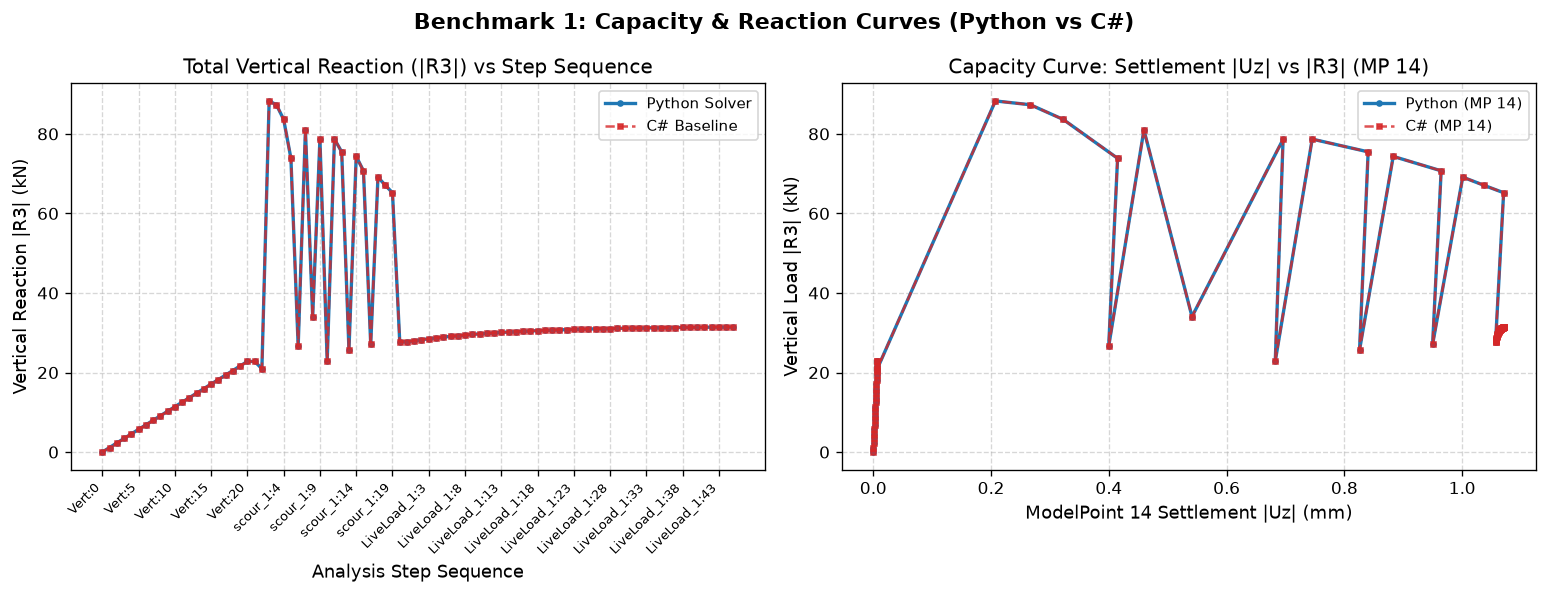

In [5]:
# Plot: Benchmark 1 Displacement vs Load
plot_displacement_vs_load(
    b1_aligned,
    title="Benchmark 1: Capacity & Reaction Curves (Python vs C#)",
)


---
# 2. Benchmark 2 (`my_model/benchmark_2`)

Multi-span masonry bridge with foundation Soil boundary springs, progressive scour stages, and line live load pushover.

**Workflow**:
1. **Self-weight (`Vert`)**: Nonlinear gravity load analysis on soil foundation.
2. **Scour Phase 1 (`scour_1`)**: Removal of first 3 rows of upstream foundation interfaces.
3. **Scour Phase 2 (`scour_2`)**: 40% foundation scour ratio.
4. **Live Load (`LiveLoad_2`)**: Line live load pushover analysis until configured limit.


In [6]:
# Load Benchmark 2 Model and C# Reference Results
b2_hrx = Path("my_model/benchmark_2/benchmark_virgin.hrx")
b2_results = Path("my_model/benchmark_2/benchmark.Results")

print(f"Loading Benchmark 2: {b2_hrx}...")
b2_model = load_model(b2_hrx)
b2_prep = ModelManager.prepare_model(b2_model)
print(f"Prepared: {b2_prep.gdl} DOFs, {b2_prep.interfaces} interfaces.")

# Resolve foundation interfaces
b2_foundation = pier_foundation_interface_keys(b2_model)
b2_scour1 = first_rows_interface_keys(b2_model, SCOUR_ROWS_1)
b2_scour2 = upstream_interface_keys(b2_model, SCOUR_RATIO_2)

print(f"Benchmark 2 interfaces: Foundation={len(b2_foundation)}, scour_1 (3 rows)={len(b2_scour1)}, scour_2 (40%)={len(b2_scour2)}")

b2_session = AnalysisSession(b2_model)
b2_session.change_interface_materials(b2_foundation, SOIL_MATERIAL_KEY, preserve_committed_state=False)

b2_executions = []
print("1. Running Vert...")
b2_executions.append(b2_session.run("Vert"))

print("2. Running scour_1...")
b2_session.change_interface_materials(b2_scour1, SOIL_REMOVED_MATERIAL_KEY)
b2_executions.append(b2_session.run("scour_1"))

print("3. Running scour_2...")
b2_session.change_interface_materials(b2_scour2, SOIL_REMOVED_MATERIAL_KEY)
b2_executions.append(b2_session.run("scour_2"))

print("4. Running LiveLoad_2 (line load pushover)...")
b2_executions.append(b2_session.run("LiveLoad_2"))

# Synchronize Step History across Full Chain
b2_aligned = build_aligned_step_history(b2_model, b2_executions, b2_results, preferred_mp_key=9)

# Scour Progression Snapshots
b2_scour_stages = [(0.0, "Vert"), (0.2, "scour_1"), (0.4, "scour_2")]
b2_scour = extract_scour_progression(b2_model, b2_executions, b2_results, b2_scour_stages)

print(f"Benchmark 2 complete. {len(b2_aligned['steps'])} total steps across all 4 analyses.")


Loading Benchmark 2: my_model/benchmark_2/benchmark_virgin.hrx...
Prepared: 1820 DOFs, 682 interfaces.
Benchmark 2 interfaces: Foundation=60, scour_1 (3 rows)=18, scour_2 (40%)=24
1. Running Vert...


/tmp/ipykernel_558150/1611951426.py:22: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-001: analysis='Vert' (key=1), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. Work can satisfy its incremental test while the active-DOF force residual remains above the independent equilibrium limit Recommendation: use ForceMoment for production equilibrium, or retain the authored criterion only with equilibrium_policy='error'. See docs/nonlinear_convergence_safety.md.
  b2_executions.append(b2_session.run("Vert"))
/tmp/ipykernel_558150/1611951426.py:22: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-004: analysis='Vert' (key=1), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. no signed full-range, model-qualified strategy evidence is attached to this analysis configuration Recommendation: run the strict strategy matrix against a traceable accepted response before treating this configuration as recommended. See docs/nonlinear_converge

2. Running scour_1...


/tmp/ipykernel_558150/1611951426.py:26: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-001: analysis='scour_1' (key=23), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. Work can satisfy its incremental test while the active-DOF force residual remains above the independent equilibrium limit Recommendation: use ForceMoment for production equilibrium, or retain the authored criterion only with equilibrium_policy='error'. See docs/nonlinear_convergence_safety.md.
  b2_executions.append(b2_session.run("scour_1"))
/tmp/ipykernel_558150/1611951426.py:26: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-004: analysis='scour_1' (key=23), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. no signed full-range, model-qualified strategy evidence is attached to this analysis configuration Recommendation: run the strict strategy matrix against a traceable accepted response before treating this configuration as recommended. See docs/nonline

3. Running scour_2...


/tmp/ipykernel_558150/1611951426.py:30: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-001: analysis='scour_2' (key=24), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. Work can satisfy its incremental test while the active-DOF force residual remains above the independent equilibrium limit Recommendation: use ForceMoment for production equilibrium, or retain the authored criterion only with equilibrium_policy='error'. See docs/nonlinear_convergence_safety.md.
  b2_executions.append(b2_session.run("scour_2"))
/tmp/ipykernel_558150/1611951426.py:30: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-004: analysis='scour_2' (key=24), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=Work. no signed full-range, model-qualified strategy evidence is attached to this analysis configuration Recommendation: run the strict strategy matrix against a traceable accepted response before treating this configuration as recommended. See docs/nonline

4. Running LiveLoad_2 (line load pushover)...


/tmp/ipykernel_558150/1611951426.py:33: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-001: analysis='LiveLoad_2' (key=25), integration=ArcLength, method=StandardInitialInterpolatedLineSearch, criterion=Work. Work can satisfy its incremental test while the active-DOF force residual remains above the independent equilibrium limit Recommendation: use ForceMoment for production equilibrium, or retain the authored criterion only with equilibrium_policy='error'. See docs/nonlinear_convergence_safety.md.
  b2_executions.append(b2_session.run("LiveLoad_2"))
/tmp/ipykernel_558150/1611951426.py:33: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-004: analysis='LiveLoad_2' (key=25), integration=ArcLength, method=StandardInitialInterpolatedLineSearch, criterion=Work. no signed full-range, model-qualified strategy evidence is attached to this analysis configuration Recommendation: run the strict strategy matrix against a traceable accepted response before treating this configuration as recommen

Benchmark 2 complete. 184 total steps across all 4 analyses.


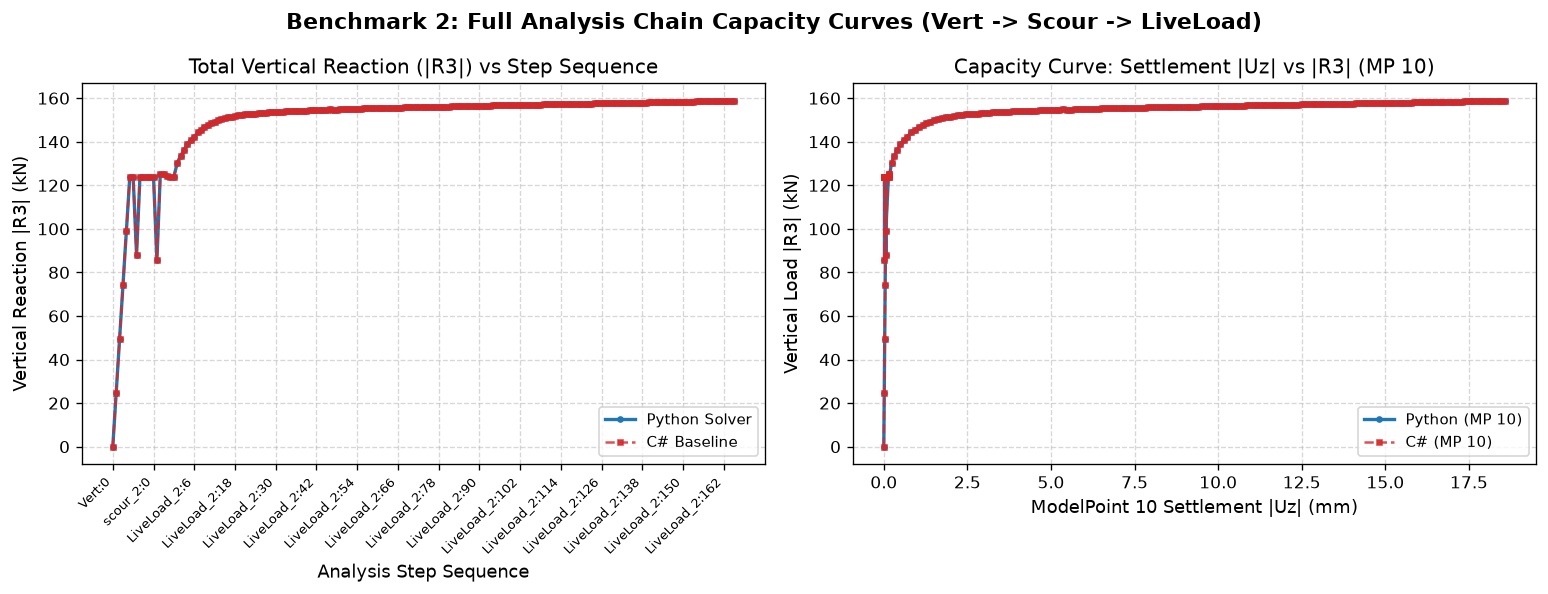

{10: (-6.129830865120312e-07, -3.5141355991363525, 1.857746183872223),
 8: (-6.133470833447063e-07, -3.5143651962280273, 0.1737288385629654),
 9: (-6.13966534501742e-07, -3.5152087211608887, -2.0741701126098633),
 11: (-2.0624793251045048e-07, -1.1822049021720886, 0.17414025962352753),
 14: (-9.731593308970332e-11, -0.0003529787063598633, 0.17445820569992065),
 16: (2.000888343900442e-10, -0.000491708517074585, 2.3499372005462646),
 13: (-2.060860424535349e-07, -1.1819708347320557, 2.349967360496521),
 15: (-1.064108801074326e-10, 0.000621795654296875, -2.566458582878113),
 12: (-2.067481545964256e-07, -1.182549238204956, -2.566466450691223)}

In [7]:
plot_displacement_vs_load(
    build_aligned_step_history(b2_model, b2_executions, b2_results, preferred_mp_key=10),
    title="Benchmark 2: Full Analysis Chain Capacity Curves (Vert -> Scour -> LiveLoad)",
    direction="Uz"
)

build_aligned_step_history(b2_model, b2_executions, b2_results, preferred_mp_key=10)['steps'][-1]['py_mps']

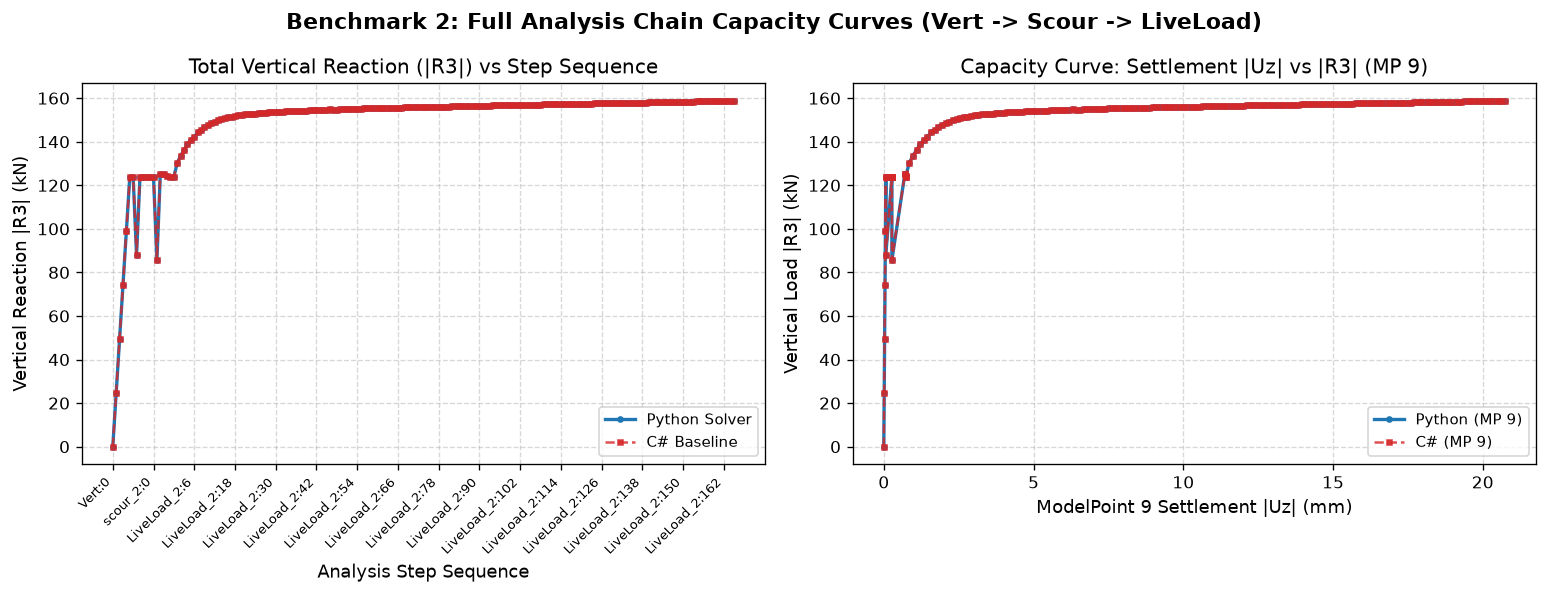

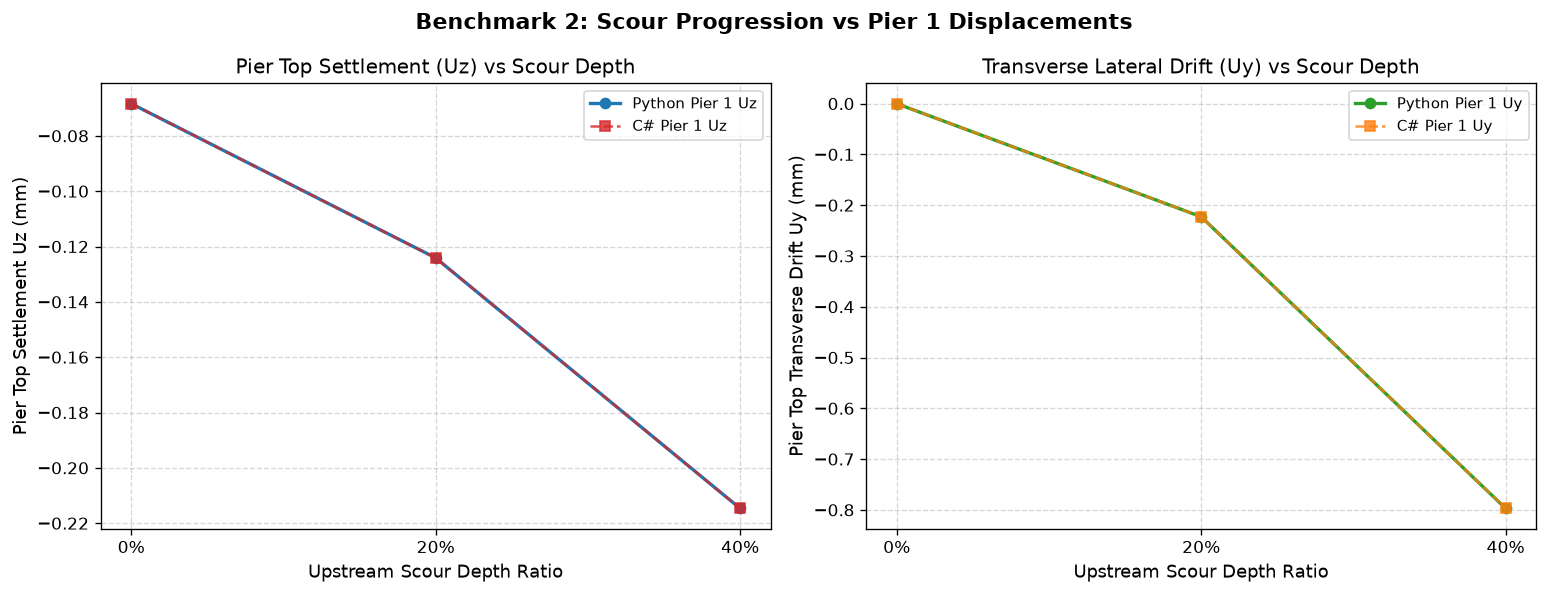

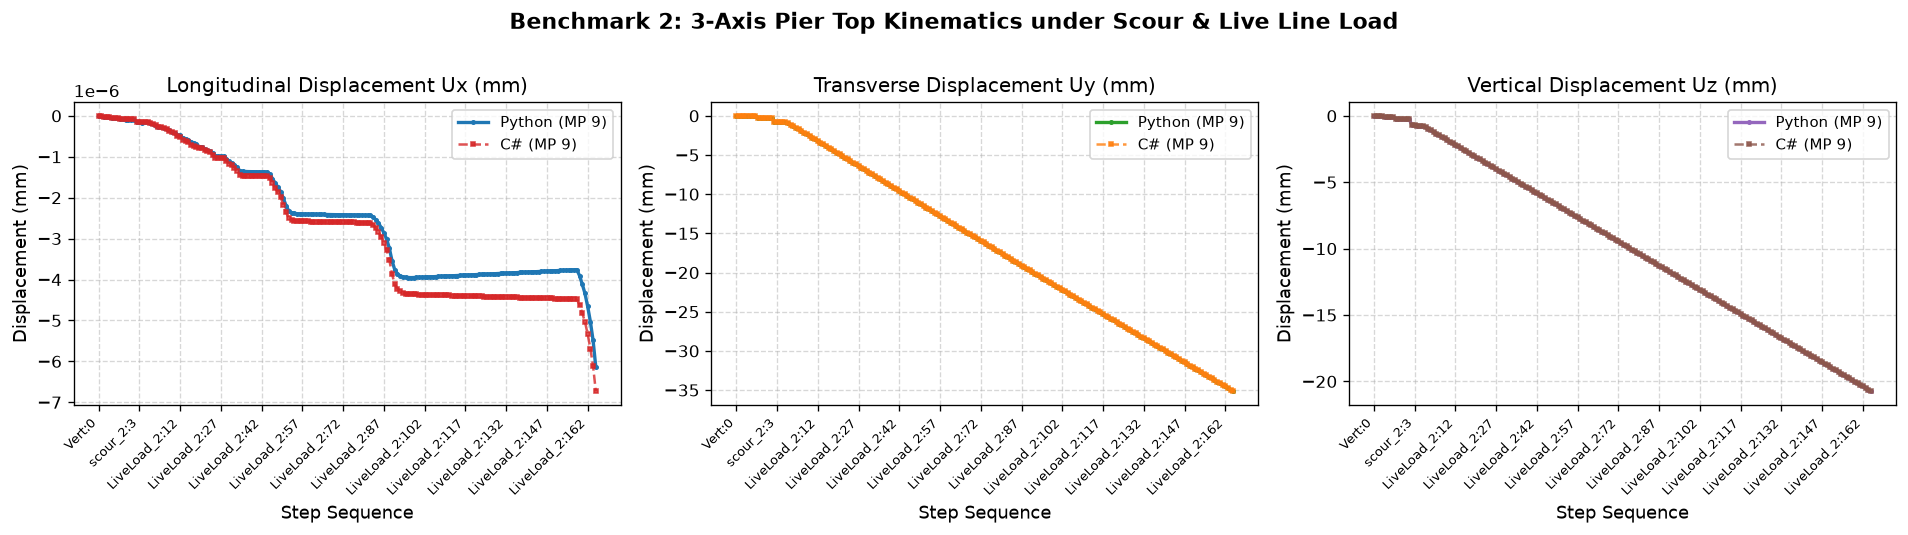

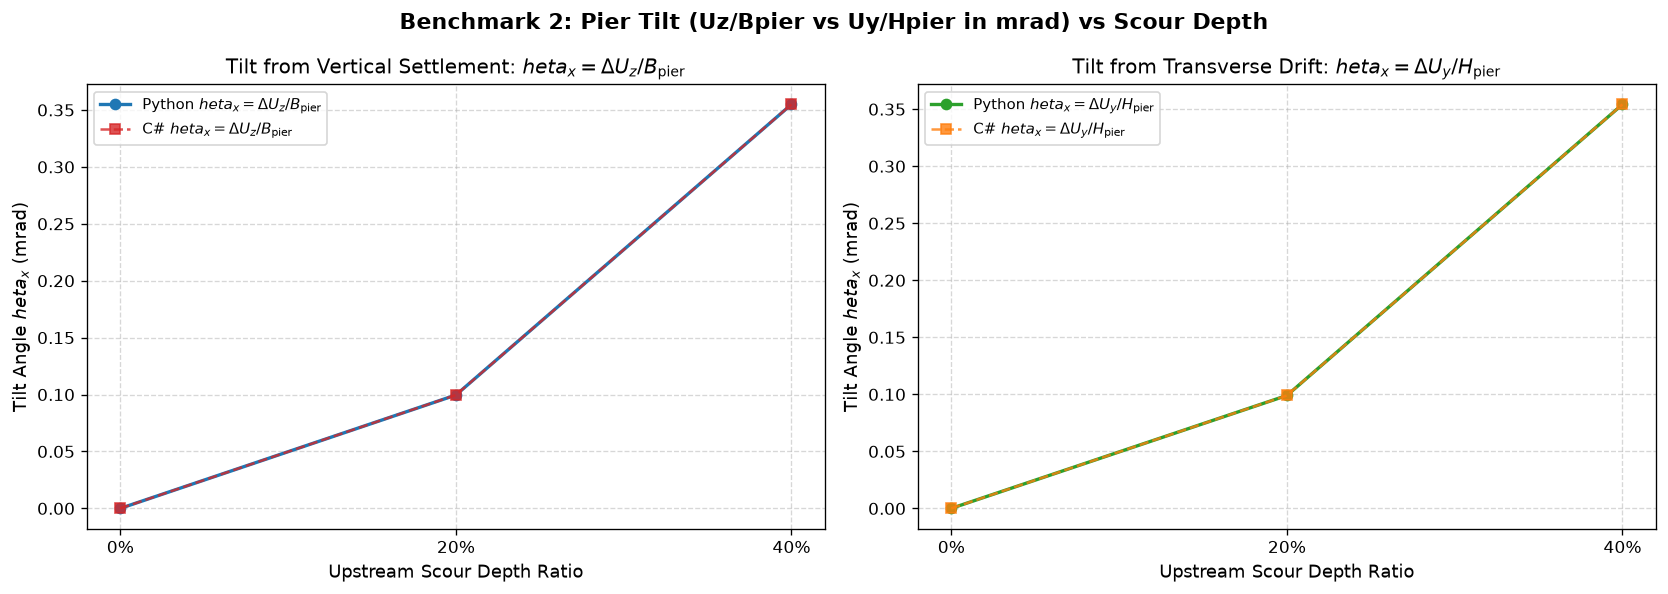

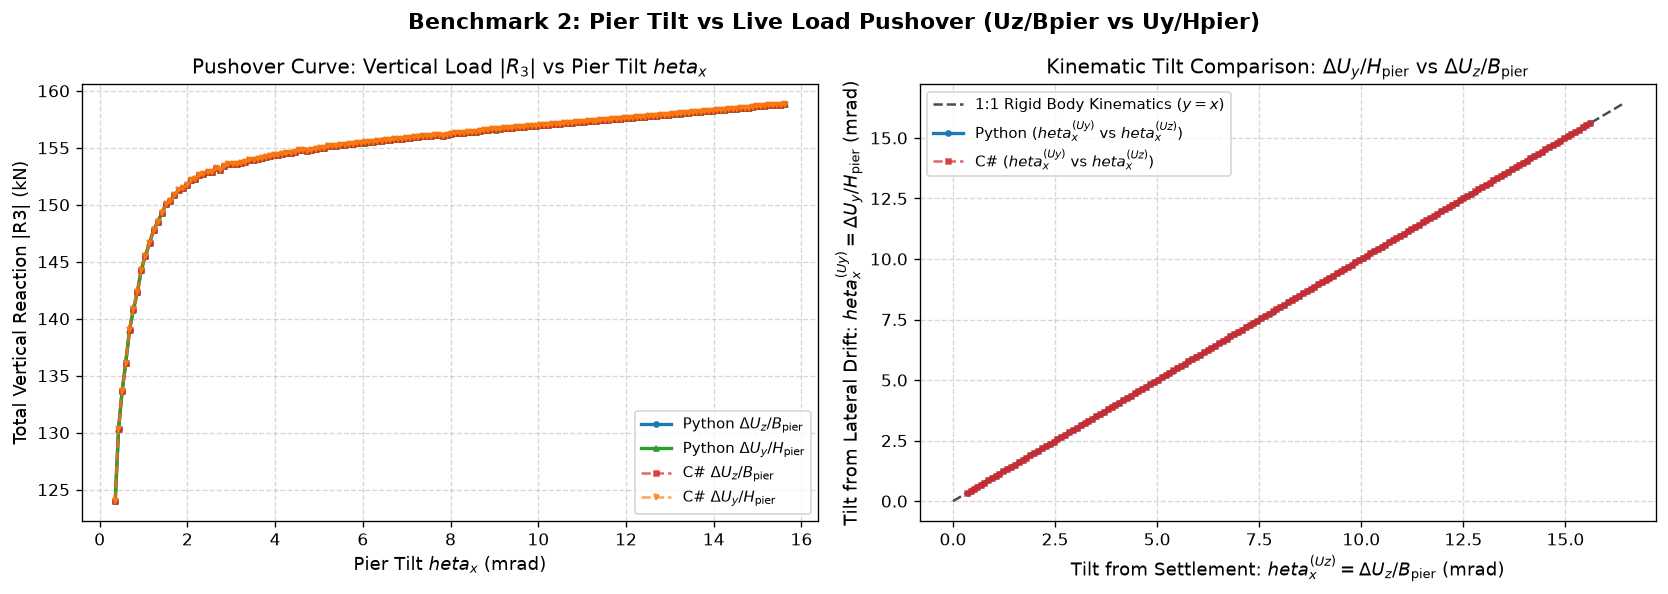

In [8]:
# Plot 1: Benchmark 2 Capacity Curve & Vertical Load vs Displacement
plot_displacement_vs_load(
    b2_aligned,
    title="Benchmark 2: Full Analysis Chain Capacity Curves (Vert -> Scour -> LiveLoad)",
)

# Plot 2: Benchmark 2 Scour Depth Ratio vs Settlement & Drift
plot_scour_vs_displacement(
    b2_scour,
    title="Benchmark 2: Scour Progression vs Pier 1 Displacements",
)

# Plot 3: Benchmark 2 3-Axis Kinematics across the Entire Analysis Chain
plot_pier_top_kinematics(
    b2_aligned,
    title="Benchmark 2: 3-Axis Pier Top Kinematics under Scour & Live Line Load",
    pier_mp=9,
)

# Plot 4: Benchmark 2 Pier Tilt in X-Direction vs Scour Depth
plot_pier_rotation(
    b2_scour,
    title="Benchmark 2: Pier Tilt (Uz/Bpier vs Uy/Hpier in mrad) vs Scour Depth",
)

# Plot 5: Benchmark 2 Pier Tilt vs Live Load Pushover
plot_pier_tilt_vs_load(
    b2_aligned,
    title="Benchmark 2: Pier Tilt vs Live Load Pushover (Uz/Bpier vs Uy/Hpier)",
    analysis_filter="LiveLoad",
)


---
# 3. Full 3D Random Bridge Models (`random_001` through `random_006`)

Each bridge variant contains **6,500+ interfaces** and **17,000+ generalized degrees of freedom**.
We execute the complete 5-step `Vert` baseline followed by progressive scour stages (`scour_1`, `scour_2`), tracking pier displacements, differential settlement, and pier tilt.


In [9]:
# ==============================================================================
# Select and Execute a Random Model
# ==============================================================================
SELECTED_JOB = "random_005"  # Options: "random_001", "random_002", "random_003", "random_004", "random_005", "random_006"

job_dir = Path("temp-six-jobs") / SELECTED_JOB
if SELECTED_JOB == "random_006":
    rand_hrx = job_dir / "random_005_copy_1.hrx"
    if not rand_hrx.exists():
        rand_hrx = job_dir / "random_005.hrx"
    rand_results = job_dir / "random_005_copy_1.Results"
else:
    rand_hrx = job_dir / f"{SELECTED_JOB}.hrx"
    rand_results = job_dir / f"{SELECTED_JOB}_copy_1.Results"

print(f"[{SELECTED_JOB}] Loading model from {rand_hrx}...")
rand_model = load_model(rand_hrx)
rand_prep = ModelManager.prepare_model(rand_model)
print(f"[{SELECTED_JOB}] Prepared: {rand_prep.gdl} DOFs, {rand_prep.interfaces} interfaces.")

# Scour interface key resolution
soil_keys = pier_foundation_interface_keys(rand_model)
scour_1_keys = upstream_interface_keys(rand_model, 0.2)
scour_2_keys = upstream_interface_keys(rand_model, 0.4)

print(f"[{SELECTED_JOB}] Soil keys: {len(soil_keys)}, Scour keys: 20%={len(scour_1_keys)}, 40%={len(scour_2_keys)}")

rand_session = AnalysisSession(rand_model)
if soil_keys:
    rand_session.change_interface_materials(soil_keys, SOIL_MATERIAL_KEY, preserve_committed_state=False)

rand_executions = []
print(f"[{SELECTED_JOB}] 1. Running Vert...")
rand_executions.append(rand_session.run("Vert"))

if scour_1_keys:
    print(f"[{SELECTED_JOB}] 2. Running scour_1 (20%)...")
    rand_session.change_interface_materials(scour_1_keys, SOIL_REMOVED_MATERIAL_KEY)
    rand_executions.append(rand_session.run("scour_1"))

if scour_2_keys:
    print(f"[{SELECTED_JOB}] 3. Running scour_2 (40%)...")
    rand_session.change_interface_materials(scour_2_keys, SOIL_REMOVED_MATERIAL_KEY)
    rand_executions.append(rand_session.run("scour_2"))

# 1. Build Aligned Step History across All Sequential Analyses
rand_aligned = build_aligned_step_history(rand_model, rand_executions, rand_results, preferred_mp_key=8)

# 2. Extract Final Converged Equilibrium States for Scour Progression
scour_stages = [(0.0, "Vert"), (0.2, "scour_1"), (0.4, "scour_2")]
rand_scour = extract_scour_progression(rand_model, rand_executions, rand_results, scour_stages)

print(f"[{SELECTED_JOB}] Extraction complete. {len(rand_aligned['steps'])} aligned steps, {len(rand_scour['stages'])} scour stages.")


[random_005] Loading model from temp-six-jobs/random_005/random_005.hrx...


FileNotFoundError: [Errno 2] No such file or directory: '/home/mauricio/coding/histra-python/temp-six-jobs/random_005/random_005.hrx'

In [ ]:
# Plot 1: Displacement vs Load for Selected Random Model
plot_displacement_vs_load(
    rand_aligned,
    title=f"{SELECTED_JOB}: Displacement vs Reaction Curves (Python vs C#)",
)


In [ ]:
# Plot 2: Scour Depth Ratio vs Pier Settlement & Transverse Drift
plot_scour_vs_displacement(
    rand_scour,
    title=f"{SELECTED_JOB}: Scour Depth Ratio vs Pier 1 Displacements",
)


In [ ]:
# Plot 3: 3-Axis Pier Top Kinematics (Ux, Uy, Uz) across Analysis Steps
plot_pier_top_kinematics(
    rand_aligned,
    title=f"{SELECTED_JOB}: 3-Axis Pier Top Kinematics under Load & Scour",
    pier_mp=8,
)

# Plot 4: Pier Tilt and Rotation Angles (theta_x from Uz/Bpier vs Uy/Hpier)
plot_pier_rotation(
    rand_scour,
    title=f"{SELECTED_JOB}: Pier Tilt in X-Direction (Uz/Bpier vs Uy/Hpier) vs Scour Depth",
)

# Plot 5: Pier Tilt vs Live Load Pushover (if live load executed)
if any("LiveLoad" in s.get("analysis_name", "") for s in rand_aligned.get("steps", [])):
    plot_pier_tilt_vs_load(
        rand_aligned,
        title=f"{SELECTED_JOB}: Pier Tilt vs Live Load Pushover",
        analysis_filter="LiveLoad",
    )


---
# 4. Multi-Model Batch Parity Benchmark (All 6 Models)

Comparative summary of **maximum displacement node deflections**, **peak discrepancies**, and **reaction totals** across all 6 random models.


In [ ]:
# Run / Compare all 6 models for Vert baseline
batch_results = []

for job_idx in range(1, 7):
    jname = f"random_{job_idx:03d}"
    jdir = Path("temp-six-jobs") / jname
    
    if job_idx == 6:
        hrx_file = jdir / "random_005_copy_1.hrx"
        if not hrx_file.exists():
            hrx_file = jdir / "random_005.hrx"
        res_file = jdir / "random_005_copy_1.Results"
    else:
        hrx_file = jdir / f"{jname}.hrx"
        res_file = jdir / f"{jname}_copy_1.Results"

    print(f"Evaluating {jname}...", end=" ", flush=True)
    m = load_model(hrx_file)
    ModelManager.prepare_model(m)
    sess = AnalysisSession(m)
    skeys = pier_foundation_interface_keys(m)
    if skeys:
        sess.change_interface_materials(skeys, SOIL_MATERIAL_KEY, preserve_committed_state=False)
    
    exec_vert = sess.run("Vert")
    py_u = exec_vert.committed_steps[-1].u
    py_r3 = exec_vert.committed_steps[-1].reaction_z

    cs_u = np.zeros_like(py_u)
    cs_r3 = 0.0
    if res_file.exists():
        with sqlite3.connect(res_file) as db:
            v_rows = db.execute("SELECT Dof, U FROM DynamicVectorsState WHERE AnalysisKey=1 AND Combination=1 ORDER BY Dof").fetchall()
            if v_rows:
                cs_u = np.array([r[1] for r in v_rows], dtype=float)
            r_rows = db.execute("SELECT R3 FROM ReactionSumStates WHERE AnalysisKey=1 AND Combination=1 ORDER BY Step DESC LIMIT 1").fetchone()
            if r_rows:
                cs_r3 = r_rows[0]

    diff = py_u - cs_u
    max_disp_idx = int(np.argmax(np.abs(cs_u)))
    max_disc_idx = int(np.argmax(np.abs(diff)))

    batch_results.append({
        "model": jname,
        "peak_csharp_mm": float(cs_u[max_disp_idx]) * 10.0,
        "peak_python_mm": float(py_u[max_disp_idx]) * 10.0,
        "peak_diff_mm": float(py_u[max_disp_idx] - cs_u[max_disp_idx]) * 10.0,
        "peak_rel_pct": abs(py_u[max_disp_idx] - cs_u[max_disp_idx]) / abs(cs_u[max_disp_idx]) * 100.0 if cs_u[max_disp_idx] else 0.0,
        "max_discrepancy_mm": float(np.max(np.abs(diff))) * 10.0,
        "reaction_diff_pct": abs(py_r3 - cs_r3) / abs(cs_r3) * 100.0 if cs_r3 else 0.0,
    })
    print(f"Peak Diff = {batch_results[-1]['peak_diff_mm']:+.3f} mm ({batch_results[-1]['peak_rel_pct']:.2f}%), Max Disc = {batch_results[-1]['max_discrepancy_mm']:.3f} mm")

print("\nBatch evaluation complete.")


In [ ]:
# Plot Multi-Model Parity Summary
models = [r["model"] for r in batch_results]
cs_peaks = [abs(r["peak_csharp_mm"]) for r in batch_results]
py_peaks = [abs(r["peak_python_mm"]) for r in batch_results]
diffs_mm = [r["max_discrepancy_mm"] for r in batch_results]
rel_errs = [r["peak_rel_pct"] for r in batch_results]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Peak Deflection Comparison
x = np.arange(len(models))
width = 0.35
ax1.bar(x - width/2, cs_peaks, width, label="C# HiStrA", color="#d62728", alpha=0.85)
ax1.bar(x + width/2, py_peaks, width, label="Python Solver", color="#1f77b4", alpha=0.85)
ax1.set_title("Peak Vertical Deflection |Uz| (mm)")
ax1.set_ylabel("Deflection (mm)")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30)
ax1.legend()
ax1.grid(True)

# 2. Maximum Discrepancy (mm)
ax2.bar(models, diffs_mm, color="#ff7f0e", alpha=0.85)
ax2.set_title("Max Displacement Discrepancy Across DOFs")
ax2.set_ylabel("Max |du| (mm)")
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=30)
ax2.grid(True)

# 3. Relative Difference at Peak Node (%)
ax3.bar(models, rel_errs, color="#2ca02c", alpha=0.85)
ax3.set_title("Relative Error at Peak Node (%)")
ax3.set_ylabel("Relative Difference (%)")
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=30)
ax3.grid(True)

fig.suptitle("6 Random Models: Python vs C# Parity Summary", fontsize=14, fontweight="bold")
plt.show()


---
# 5. Benchmark 3: Geometric Nonlinearity & Convergence Strategies Comparison

Comparison of the 3 live load convergence strategies defined in the updated Benchmark 3 model:
1. `LiveLoad_displacement` (AnalysisKey 22, `DispRotation`, `tol=5e-4`)
2. `LiveLoad_1_force` (AnalysisKey 24, `ForceMoment`, `tol=5e-4`)
3. `LiveLoad_1_work` (AnalysisKey 25, `Work`, `tol=5e-4`)

Each analysis branches from `scour_1` (which follows `Vert`), and is solved for both **Linear Geometry (No P-Delta)** and **Geometric Nonlinearity (With P-Delta)**, then validated against C# `.Results` databases.


In [10]:
# ==============================================================================
# Benchmark 3 Configuration & Helper Runner
# ==============================================================================
import os
import time
import sqlite3
import concurrent.futures
import matplotlib.pyplot as plt
from pathlib import Path
from histra.io.hr_loader import load_model
from histra.solver import AnalysisSession
from histra.solver.model_manager import ModelManager
from histra.solver.output_projection import compute_model_point_displacements

# Paths to HRX models and C# result databases
b3_no_pd_hrx = Path("my_model/benchmark_3_Pdelta/benchmark_virgin_NoPDelta.hrx")
b3_pd_hrx = Path("my_model/benchmark_3_Pdelta/benchmark_virgin_PDelta.hrx")
b3_no_pd_results = Path("my_model/benchmark_3_Pdelta/benchmark_virgin_NoPDelta.Results")
b3_pd_results = Path("my_model/benchmark_3_Pdelta/benchmark_virgin_PDelta.Results")

def run_benchmark_named(hrx_path, live_analysis_name, pdelta_override=None, max_steps=80, verbose=False):
    """Run Vert -> scour_1 -> named live load analysis directly from the configured HRX."""
    model = load_model(hrx_path)
    if pdelta_override is not None:
        for a in model.collections.analyses.values():
            a.pdelta_effect = pdelta_override
            
    # Allow ForceMoment enough iterations to reach strict equilibrium without warnings
    for a in model.collections.analyses.values():
        if getattr(a, "adaptive_convergence_criteria", "") == "ForceMoment" and getattr(a, "max_iterations", 0) < 40000:
            a.max_iterations = 40000

    # Keep gravity stages (Vert, scour_1) on ModifiedRegulaFalsiLineSearch;
    # Apply StandardRegulaFalsiLineSearch to the target Live Load pushover stage for quadratic speedup (<15s)
    live_an = next(x for x in model.collections.analyses.values() if x.name == live_analysis_name)
    live_an.method = "StandardRegulaFalsiLineSearch"
            
    ModelManager.prepare_model(model)
    
    session = AnalysisSession(
        model,
        on_log=(lambda text: print(f"  {text}", flush=True)) if verbose else None
    )
    exec_vert = session.run("Vert")
    exec_scour = session.run("scour_1")
    exec_live = session.run(live_analysis_name, max_committed_steps=max_steps)
    return model, [exec_vert, exec_scour, exec_live]


In [85]:
### I am just trying to run a benchmark. This cell makes no sens here.


hrx_path = Path("my_model/benchmark_3_Pdelta/benchmark_virgin_NoPDelta.hrx")

model = load_model(hrx_path)

for a in model.collections.analyses.values():
    a.pdelta_effect = "none"
        
# Allow ForceMoment enough iterations to reach strict equilibrium without warnings
#for a in model.collections.analyses.values():
    #if getattr(a, "adaptive_convergence_criteria", "") == "ForceMoment" and getattr(a, "max_iterations", 0) < 40000:
        #a.max_iterations = 40000
        
ModelManager.prepare_model(model)

session = AnalysisSession(
    model,
    #on_log=(lambda text: print(f"  {text}", flush=True)) if verbose else None
)
exec_vert = session.run("Vert")

/tmp/ipykernel_558150/3205270018.py:22: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-004: analysis='Vert' (key=1), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=ForceMoment. no signed full-range, model-qualified strategy evidence is attached to this analysis configuration Recommendation: run the strict strategy matrix against a traceable accepted response before treating this configuration as recommended. See docs/nonlinear_convergence_safety.md.
  exec_vert = session.run("Vert")


In [86]:
for a  in model.collections.nodes.values():
    if a.key == model.collections.model_points[9].element_key:
        print(a)

Node(key=2267, point=Point(x=502.0, y=-126.0, z=0.0), name='2')


In [87]:
#exec_vert.steps[0]['u'] 1820


last = exec_vert.committed_steps[4]

point_9 = next(
    row
    for row in compute_model_point_displacements(
        model,
        last.u,
        step=last.step,
        model_point_ids=(2267,),  # node referenced by model point 9
    )
    if row.parent_key == 9
)

print(f"Step: {point_9.step}")
print(f"Ux, Uy, Uz (internal length units): {point_9.ux}, {point_9.uy}, {point_9.uz}")
print(f"Uz (mm): {point_9.uz * 10.0}")

Step: 5
Ux, Uy, Uz (internal length units): -1.2383033487495254e-10, -0.0011876842472702265, -0.0013702664291486144
Uz (mm): -0.013702664291486144


In [77]:
# ==============================================================================
# Run All 3 Live Load Convergence Strategies in Parallel (No P-Delta & With P-Delta)
# ==============================================================================

analyses_to_run = [
    ("LiveLoad_displacement", 22, "DispRotation (tol=5e-4)"),
    ("LiveLoad_1_force", 24, "ForceMoment (tol=5e-4)"),
    ("LiveLoad_1_work", 25, "Work (tol=5e-4)"),
]

# 6 Tasks: 3 analyses x (No P-Delta, With P-Delta)
tasks = []
for an_name, akey, label in analyses_to_run:
    tasks.append((an_name, akey, label, "None", b3_no_pd_hrx, 80))
    tasks.append((an_name, akey, label, "EachStep", b3_pd_hrx, 80))

def _run_single_task(args):
    an_name, akey, label, pdelta, hrx_path, max_steps = args
    t0 = time.perf_counter()
    model, execs = run_benchmark_named(
        hrx_path, an_name, pdelta_override=pdelta, max_steps=max_steps, verbose=False
    )
    elapsed = time.perf_counter() - t0
    return an_name, akey, label, pdelta, model, execs, elapsed

strategy_results = {an_name: {"label": label, "key": akey} for an_name, akey, label in analyses_to_run}

num_workers = min(os.cpu_count() or 4, len(tasks))
print(f"Launching {len(tasks)} analyses in parallel across {num_workers} processes...\n")
t_start = time.perf_counter()

with concurrent.futures.ProcessPoolExecutor(max_workers=num_workers) as executor:
    futures = [executor.submit(_run_single_task, t) for t in tasks]
    for fut in concurrent.futures.as_completed(futures):
        an_name, akey, label, pdelta, model, execs, elapsed = fut.result()
        num_steps = len(execs[2].steps)
        print(f"✓ Finished: {an_name:23s} | P-Delta={pdelta:8s} | {num_steps:2d} steps in {elapsed:6.1f}s")
        
        if pdelta == "None":
            strategy_results[an_name]["no_pdelta_model"] = model
            strategy_results[an_name]["no_pdelta"] = execs
        else:
            strategy_results[an_name]["pdelta_model"] = model
            strategy_results[an_name]["with_pdelta"] = execs

t_total = time.perf_counter() - t_start
print(f"\nAll analyses completed in {t_total:.1f}s ({t_total/60.0:.2f} min)!")


Launching 6 analyses in parallel across 6 processes...



/tmp/ipykernel_558150/841587051.py:44: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-004: analysis='Vert' (key=1), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=ForceMoment. no signed full-range, model-qualified strategy evidence is attached to this analysis configuration Recommendation: run the strict strategy matrix against a traceable accepted response before treating this configuration as recommended. See docs/nonlinear_convergence_safety.md.
  exec_vert = session.run("Vert")
/tmp/ipykernel_558150/841587051.py:44: SuboptimalSolverStrategyWarning: HISTRA-STRATEGY-004: analysis='Vert' (key=1), integration=LoadControl, method=ModifiedRegulaFalsiLineSearch, criterion=ForceMoment. no signed full-range, model-qualified strategy evidence is attached to this analysis configuration Recommendation: run the strict strategy matrix against a traceable accepted response before treating this configuration as recommended. See docs/nonlinear_convergence_safety.md.
  ex

✓ Finished: LiveLoad_1_work         | P-Delta=EachStep | 20 steps in    9.2s
✓ Finished: LiveLoad_1_work         | P-Delta=None     | 21 steps in    9.7s
✓ Finished: LiveLoad_displacement   | P-Delta=None     | 21 steps in   10.0s
✓ Finished: LiveLoad_1_force        | P-Delta=None     | 21 steps in   11.0s
✓ Finished: LiveLoad_1_force        | P-Delta=EachStep | 20 steps in   11.5s
✓ Finished: LiveLoad_displacement   | P-Delta=EachStep | 20 steps in   12.2s

All analyses completed in 14.9s (0.25 min)!


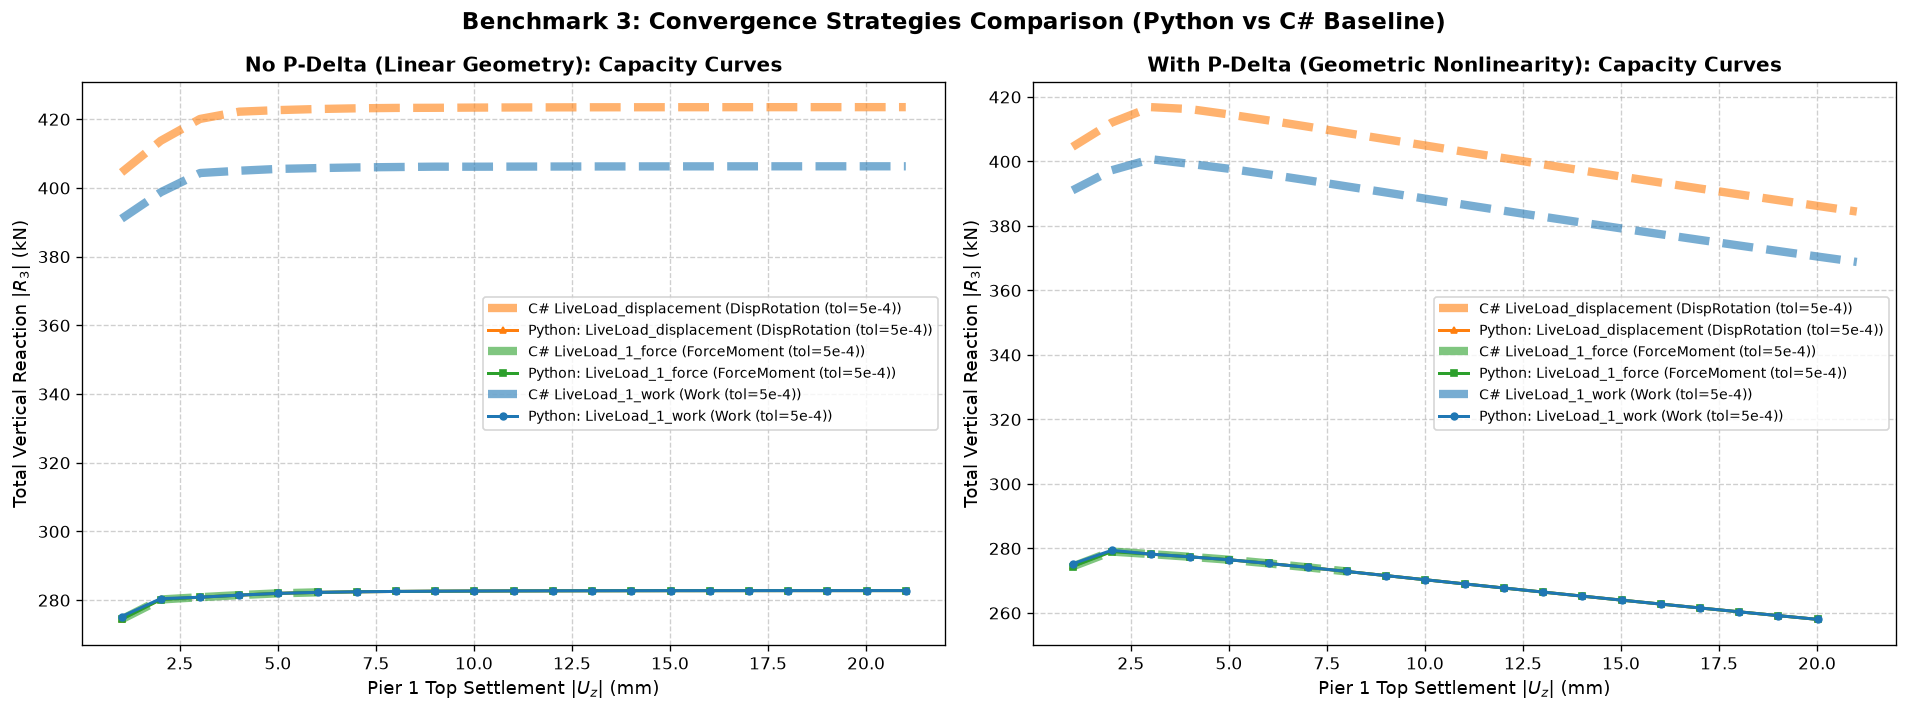

In [78]:
# ==============================================================================
# Plot: 3 Live Load Convergence Strategies vs C# Reference Curves
# ==============================================================================

def load_csharp_analysis_curve(results_path: Path, analysis_key: int):
    """Load C# settlement (Uz) and vertical reaction (R3) for a given AnalysisKey."""
    con = sqlite3.connect(results_path)
    cur = con.cursor()
    r_rows = cur.execute("SELECT Step, R3 FROM ReactionSumStates WHERE AnalysisKey=? ORDER BY Step", (analysis_key,)).fetchall()
    reactions = {r[0]: r[1] for r in r_rows}
    mp_rows = cur.execute("SELECT Step, Uz FROM DisplModelPoints WHERE AnalysisKey=? AND ParentKey=9 ORDER BY Step", (analysis_key,)).fetchall()
    mps = {r[0]: abs(r[1]) * 10.0 for r in mp_rows}  # cm -> mm
    con.close()
    steps = sorted(reactions.keys())
    return [mps.get(s, 0.0) for s in steps if s > 0], [abs(reactions[s]) for s in steps if s > 0]

def extract_liveload_curve(model, execs):
    """Extract Master Point 9 settlement and reaction from the live load execution."""
    if isinstance(execs, list):
        live_exec = next(
            (e for e in execs if getattr(e, "analysis_name", "") in ("LiveLoad_displacement", "LiveLoad_1_force", "LiveLoad_1_work")),
            execs[-1]
        )
    else:
        live_exec = execs
        
    uz_list = []
    r3_list = []
    steps = getattr(live_exec, "steps", live_exec) if live_exec is not None else []
    
    for s in steps:
        if isinstance(s, dict):
            u_vec = s.get("u")
            step_num = s.get("step", 0)
            disp_fallback = s.get("displacement", 0.0)
            r3_val = s.get("reaction_z", s.get("balancing_reaction_z", s.get("R3", 0.0)))
        else:
            u_vec = getattr(s, "u", None)
            step_num = getattr(s, "step", 0)
            disp_fallback = getattr(s, "displacement", 0.0)
            r3_val = getattr(s, "reaction_z", getattr(s, "balancing_reaction_z", getattr(s, "R3", 0.0)))
            
        if u_vec is not None and len(u_vec) > 0:
            mps = {
                m.parent_key: (m.ux, m.uy, m.uz)
                for m in compute_model_point_displacements(model, u_vec, step=step_num)
            }
            uz = abs(mps.get(9, (0, 0, 0))[2]) * 10.0  # cm -> mm
        else:
            uz = 0.0
            
        if uz == 0.0 and disp_fallback is not None:
            uz = abs(disp_fallback) * 10.0
            
        uz_list.append(uz)
        r3_list.append(abs(float(r3_val if r3_val is not None else 0.0)))
        
    return uz_list, r3_list

colors = {
    "LiveLoad_displacement": "#ff7f0e",
    "LiveLoad_1_force": "#2ca02c",
    "LiveLoad_1_work": "#1f77b4",
}
markers = {
    "LiveLoad_displacement": "^-",
    "LiveLoad_1_force": "s-",
    "LiveLoad_1_work": "o-",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: No P-Delta (Linear Geometry)
for an_name, akey, label in analyses_to_run:
    # C# Baseline
    cs_uz, cs_r3 = load_csharp_analysis_curve(b3_no_pd_results, akey)
    if cs_uz:
        axes[0].plot(cs_uz, cs_r3, "--", color=colors[an_name], alpha=0.6, lw=5.0, label=f"C# {an_name} ({label})")
    
    # Python
    data = strategy_results[an_name]
    if "no_pdelta_model" in data and "no_pdelta" in data:
        py_uz, py_r3 = extract_liveload_curve(data["no_pdelta_model"], data["no_pdelta"])
        axes[0].plot(
            py_uz, py_r3, markers[an_name], color=colors[an_name], lw=1.8, ms=4,
            label=f"Python: {an_name} ({data['label']})"
        )

axes[0].set_title("No P-Delta (Linear Geometry): Capacity Curves", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Pier 1 Top Settlement $|U_z|$ (mm)", fontsize=11)
axes[0].set_ylabel("Total Vertical Reaction $|R_3|$ (kN)", fontsize=11)
axes[0].legend(fontsize=8.5)
axes[0].grid(True, linestyle="--", alpha=0.6)

# Panel 2: With P-Delta (Geometric Nonlinearity)
for an_name, akey, label in analyses_to_run:
    # C# Baseline
    cs_uz, cs_r3 = load_csharp_analysis_curve(b3_pd_results, akey)
    if cs_uz:
        axes[1].plot(cs_uz, cs_r3, "--", color=colors[an_name], alpha=0.6, lw=5.0, label=f"C# {an_name} ({label})")
    
    # Python
    data = strategy_results[an_name]
    if "pdelta_model" in data and "with_pdelta" in data:
        py_uz, py_r3 = extract_liveload_curve(data["pdelta_model"], data["with_pdelta"])
        axes[1].plot(
            py_uz, py_r3, markers[an_name], color=colors[an_name], lw=1.8, ms=4,
            label=f"Python: {an_name} ({data['label']})"
        )

axes[1].set_title("With P-Delta (Geometric Nonlinearity): Capacity Curves", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Pier 1 Top Settlement $|U_z|$ (mm)", fontsize=11)
axes[1].set_ylabel("Total Vertical Reaction $|R_3|$ (kN)", fontsize=11)
axes[1].legend(fontsize=8.5)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Benchmark 3: Convergence Strategies Comparison (Python vs C# Baseline)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
